# PYTHON Exploratory-Data-Analysis:

# IMPORT REQUIRED LIBRARIES:


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud


import warnings
warnings.filterwarnings('ignore')


In [15]:

df = pd.read_csv("netflix_titles.csv")
print("Initial shape:", df.shape)
df.head()


Initial shape: (6234, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China","September 9, 2019",2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...
1,80117401,Movie,Jandino: Whatever it Takes,NaN,Jandino Asporaat,United Kingdom,"September 9, 2016",2016,TV-MA,94 min,Stand-Up Comedy,Jandino Asporaat riffs on the challenges of ra...
2,70234439,TV Show,Transformers Prime,NaN,"Peter Cullen, Sumalee Montano, Frank Welker, J...",United States,"September 8, 2018",2013,TV-Y7-FV,1 Season,Kids' TV,"With the help of three human allies, the Autob..."
3,80058654,TV Show,Transformers: Robots in Disguise,NaN,"Will Friedle, Darren Criss, Constance Zimmer, ...",United States,"September 8, 2018",2016,TV-Y7,1 Season,Kids' TV,When a prison ship crash unleashes hundreds of...
4,80125979,Movie,#realityhigh,Fernando Lebrija,"Nesta Cooper, Kate Walsh, John Michael Higgins...",United States,"September 8, 2017",2017,TV-14,99 min,Comedies,When nerdy high schooler Dani finally attracts...


# DATA CLEANING:

In [16]:

print("\nMissing values per column:\n")
print(df.isnull().sum())

df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)
df['rating'].fillna('Unknown', inplace=True)
df['duration'].fillna('Unknown', inplace=True)
df['date_added'].fillna('Unknown', inplace=True)

df.drop_duplicates(inplace=True)

df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Extract Year and Month from date_added
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month_name()

# Extract numeric duration (for Movies only)
def extract_duration(x):
    try:
        if 'min' in x:
            return int(x.split()[0])
        else:
            return np.nan
    except:
        return np.nan

df['duration_num'] = df['duration'].apply(extract_duration)

df['primary_country'] = df['country'].apply(lambda x: x.split(',')[0] if x != 'Unknown' else 'Unknown')



Missing values per column:

show_id            0
type               0
title              0
director        1969
cast             570
country          476
date_added        11
release_year       0
rating            10
duration           0
listed_in          0
description        0
dtype: int64


# EDA:


Dataset after cleaning and feature creation:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6234 entries, 0 to 6233
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   show_id          6234 non-null   int64         
 1   type             6234 non-null   object        
 2   title            6234 non-null   object        
 3   director         6234 non-null   object        
 4   cast             6234 non-null   object        
 5   country          6234 non-null   object        
 6   date_added       5583 non-null   datetime64[ns]
 7   release_year     6234 non-null   int64         
 8   rating           6234 non-null   object        
 9   duration         6234 non-null   object        
 10  listed_in        6234 non-null   object        
 11  description      6234 non-null   object        
 12  year_added       5583 non-null   float64       
 13  month_added      5583 non-null   object       

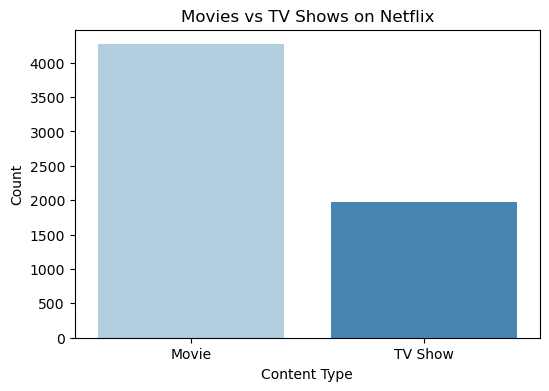

In [17]:

print("\nDataset after cleaning and feature creation:\n")
print(df.info())


# 1. NUMBER OF MOVIES v/s TV Shows:
plt.figure(figsize=(6,4))
sns.countplot(x='type', data=df, palette='Blues')
plt.title('Movies vs TV Shows on Netflix')
plt.xlabel('Content Type')
plt.ylabel('Count')
plt.show()


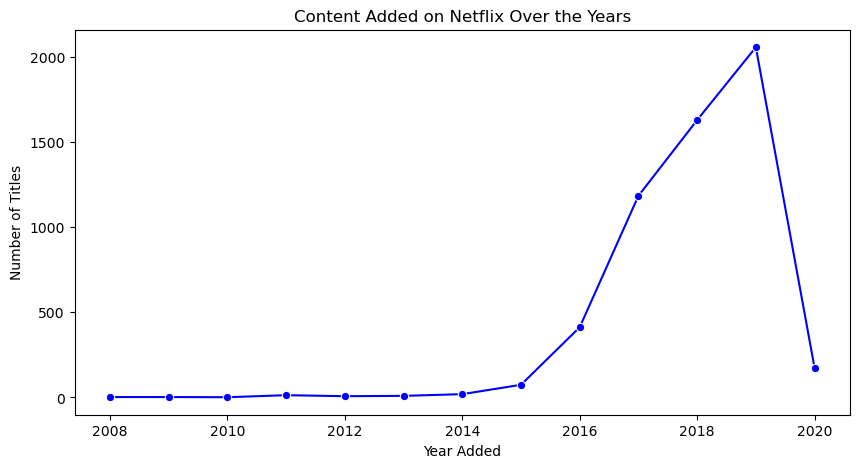

In [18]:

# 2. YEARLY TRENDS:
yearly_count = df['year_added'].value_counts().sort_index()
plt.figure(figsize=(10,5))
sns.lineplot(x=yearly_count.index, y=yearly_count.values, marker='o', color='blue')
plt.title('Content Added on Netflix Over the Years')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.show()


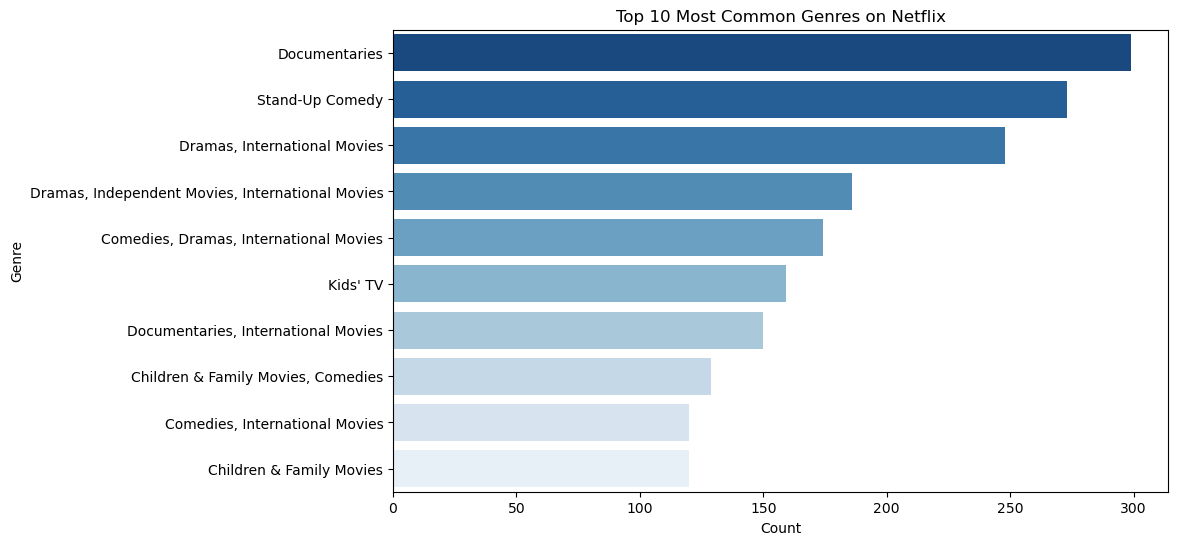

In [19]:


# 3. HIGH PERFORMANCE GENRES:
plt.figure(figsize=(10,6))
genre_data = df['listed_in'].value_counts().head(10)
sns.barplot(y=genre_data.index, x=genre_data.values, palette='Blues_r')
plt.title('Top 10 Most Common Genres on Netflix')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.show()

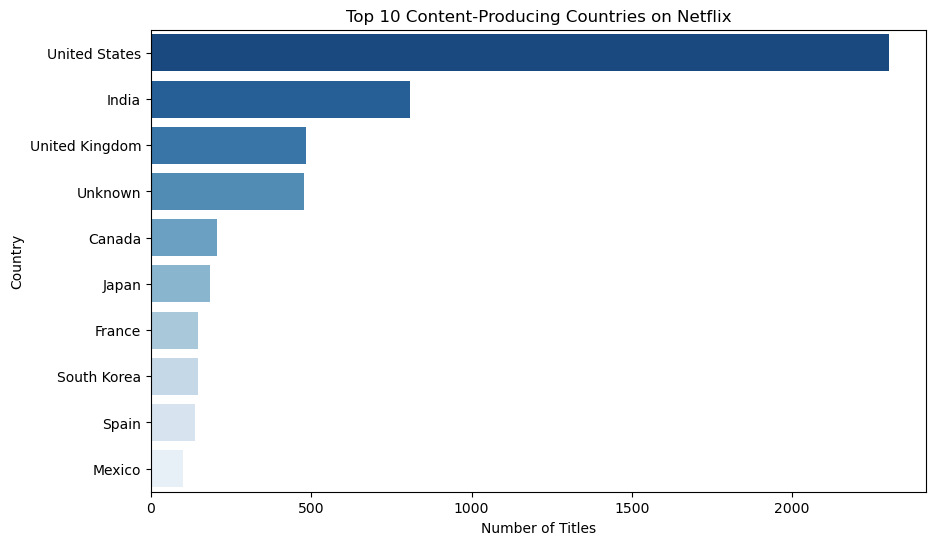

In [20]:


# 4. TOP-10 CONTRIBUTING COUNTRIES:
country_data = df['primary_country'].value_counts().head(10)
plt.figure(figsize=(10,6))
sns.barplot(y=country_data.index, x=country_data.values, palette='Blues_r')
plt.title('Top 10 Content-Producing Countries on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.show()


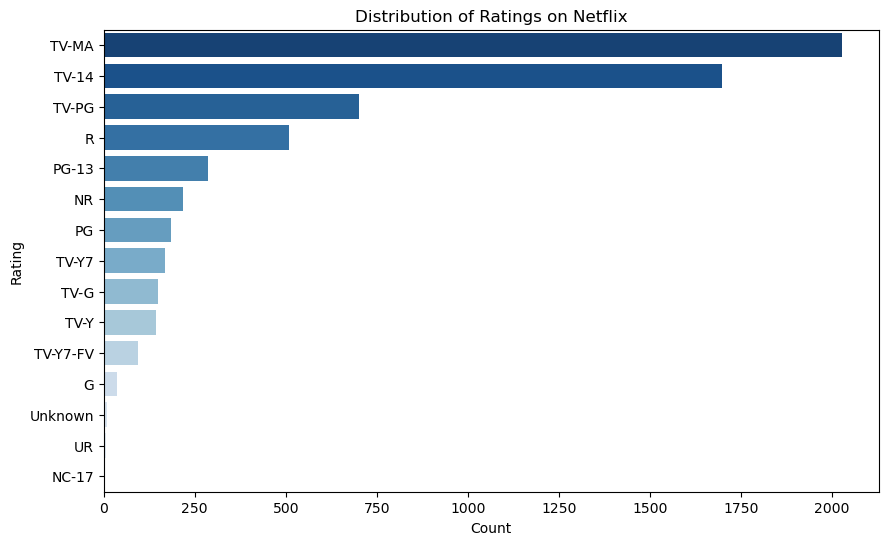

In [21]:

# 5.RATINGS DISTRIBUTION:
plt.figure(figsize=(10,6))
sns.countplot(y='rating', data=df, order=df['rating'].value_counts().index, palette='Blues_r')
plt.title('Distribution of Ratings on Netflix')
plt.xlabel('Count')
plt.ylabel('Rating')
plt.show()



In [22]:
# 6. AVERAGE DURATION OF MOVIES:
avg_duration = df[df['type']=='Movie']['duration_num'].mean()
print(f"\nAverage Movie Duration: {avg_duration:.2f} minutes")



Average Movie Duration: 99.10 minutes


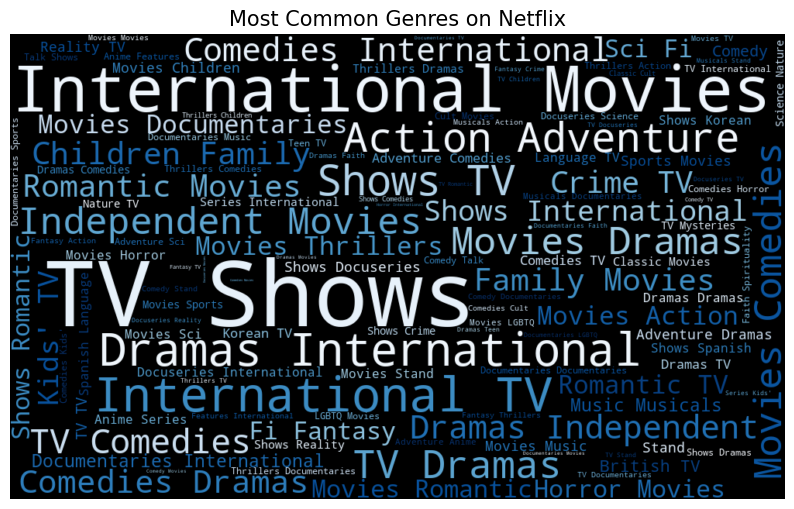

In [23]:

# 7. GENRES WORDCLOUD: 
plt.figure(figsize=(10,7))
text = ' '.join(df['listed_in'].dropna().astype(str))
wordcloud = WordCloud(width=1000, height=600, background_color='black', colormap='Blues').generate(text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Genres on Netflix', fontsize=15)
plt.show()

In [24]:
df_directors = df.copy()
df_directors["director"] = df_directors["director"].str.split(',')
df_directors=df_directors.explode("director").reset_index(drop=True)
df_directors.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,duration_num,primary_country
0,81145628,Movie,Norm of the North: King Sized Adventure,Richard Finn,"Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China",2019-09-09,2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...,2019.0,September,90.0,United States
1,81145628,Movie,Norm of the North: King Sized Adventure,Tim Maltby,"Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China",2019-09-09,2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...,2019.0,September,90.0,United States
2,80117401,Movie,Jandino: Whatever it Takes,Unknown,Jandino Asporaat,United Kingdom,2016-09-09,2016,TV-MA,94 min,Stand-Up Comedy,Jandino Asporaat riffs on the challenges of ra...,2016.0,September,94.0,United Kingdom
3,70234439,TV Show,Transformers Prime,Unknown,"Peter Cullen, Sumalee Montano, Frank Welker, J...",United States,2018-09-08,2013,TV-Y7-FV,1 Season,Kids' TV,"With the help of three human allies, the Autob...",2018.0,September,NaN,United States
4,80058654,TV Show,Transformers: Robots in Disguise,Unknown,"Will Friedle, Darren Criss, Constance Zimmer, ...",United States,2018-09-08,2016,TV-Y7,1 Season,Kids' TV,When a prison ship crash unleashes hundreds of...,2018.0,September,NaN,United States


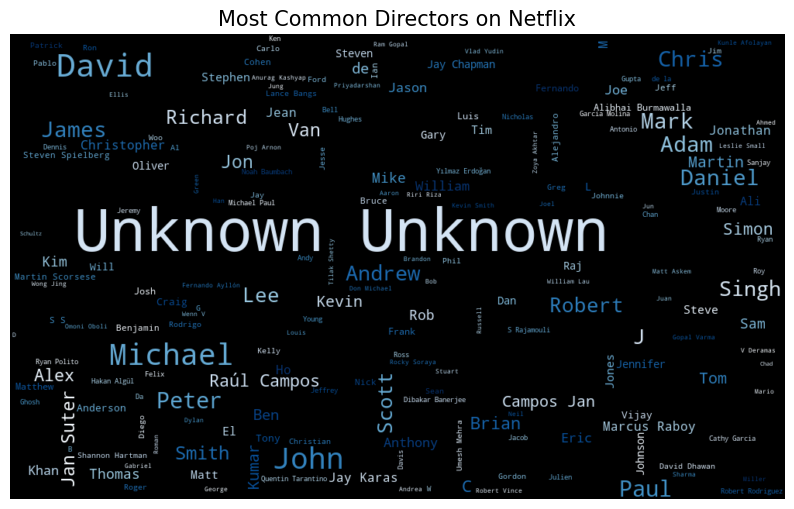

In [25]:
# 8. DIRECTORS WORDCLOUD: 
plt.figure(figsize=(10,7))
text = ' '.join(df_directors['director'].dropna().astype(str))
wordcloud = WordCloud(width=1000, height=600, background_color='black', colormap='Blues').generate(text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Directors on Netflix', fontsize=15)
plt.show()

In [26]:


# 9. COUNTRIES-WISE MAP:
try:
    import plotly.express as px
    country_counts = df['primary_country'].value_counts().reset_index()
    country_counts.columns = ['country', 'count']
    fig = px.choropleth(country_counts, locations='country', locationmode='country names',
                        color='count', title='Netflix Content by Country',
                        color_continuous_scale='Blues')
    fig.show()
except:
    print("Plotly not installed. Install via: pip install plotly")

# SAVE CLEANED DATA:
df.to_csv("netflix_cleaned.csv", index=False)
print("\n Data cleaning complete. File saved as netflix_cleaned.csv")


 Data cleaning complete. File saved as netflix_cleaned.csv



# **Netflix Titles Dataset — Storytelling & Insights (EDA Report)**

## ## **1. Introduction – What This Analysis Is About**

Netflix hosts thousands of movies and TV shows across genres and countries.
In this analysis, we explore:

* What types of content Netflix hosts
* Which countries contribute the most
* Which genres dominate
* How the content library has grown
* Audience rating patterns
* Duration trends
* Popular directors and themes

This storytelling section explains the insights discovered during the Exploratory Data Analysis (EDA) of the **Netflix Titles Dataset (6,234 records)**.

---

## ## **2. Data Overview**

The dataset (`netflix_titles.csv`) includes:

* Title, type (Movie/TV Show)
* Director & cast
* Country of origin
* Date added to Netflix
* Release year
* Rating
* Duration
* Listed genres
* Description

Before analysis, the data required cleaning to ensure accuracy.

---

## ## **3. Data Cleaning Summary**

Key cleaning steps performed:

### ** Handling Missing Values**

* Replaced missing values in `director`, `cast`, `country`, `rating`, `duration`, `date_added` with `"Unknown"`.

### ** Removing Duplicates**

* Duplicate records were removed.

### ** Converting Columns**

* Converted `date_added` to a proper datetime format.
* Extracted:

  * `year_added`
  * `month_added`
* Extracted numeric duration (for movies only).

### ** Structuring Country Info**

* Created `primary_country` containing only the first country listed.

After cleaning, the dataset was consistent and ready for exploration.

---

## ## **4. Insights & Storytelling**

---

## ### **4.1 Movies vs TV Shows**

Netflix hosts more **Movies** than **TV Shows**.

**Insight:**
Movies form the majority of Netflix’s library, but TV shows remain vital for keeping users engaged through long-form content.

---

## ### **4.2 Netflix Library Growth Over the Years**

Plotting content by `year_added` shows a major rise between **2015 to 2020**, after which additions stabilize.

**Insight:**
This period aligns with Netflix’s global expansion and shift toward producing original content.

---

## ### **4.3 Top Content Genres**

The most common genres include:

* International Movies
* Dramas
* Comedies
* Documentaries
* Action & Adventure

**Insight:**
Drama and International content dominate, indicating Netflix’s focus on global audiences and diverse storytelling.

---

## ### **4.4 Top Contributing Countries**

The top content-producing countries:

1. United States
2. India
3. United Kingdom
4. Canada
5. Japan

**Insight:**
The US is the largest contributor, but India’s rising position reflects Netflix’s investment in regional markets.

---

## ### **4.5 Ratings Distribution**

Most common ratings:

* TV-MA
* TV-14
* TV-PG

**Insight:**
Netflix leans heavily toward **mature content**, which attracts adult audiences globally.

---

## ### **4.6 Average Movie Duration**

Average movie duration on Netflix: **~99 minutes**

**Insight:**
Most Netflix movies follow the standard film length of 90–110 minutes.

---

## ### **4.7 Genre Word Cloud**

A word cloud generated from `listed_in` highlights:

* Drama
* Comedy
* International
* Documentary
* Action

**Insight:**
These categories reflect Netflix’s core content pillars.

---

## ### **4.8 Director Frequency**

After splitting director names, a director word cloud reveals recurring creators.

**Insight:**
Certain directors appear frequently, especially in documentaries, comedy specials, and international titles.

---

## ### **4.9 Country-Wise Global View**

A choropleth map shows wide global participation, with strong contributions from North America, Europe, and Asia.

**Insight:**
Netflix’s catalog has global diversity, aligning with its international user base.

---

## ## **5. Conclusion – What the Data Tells Us**

This EDA reveals that Netflix:

* Primarily hosts **Movies**, with steady growth in TV content.
* Expanded rapidly between **2015–2020**.
* Focuses heavily on **Drama**, **Comedy**, and **International** genres.
* Receives major content contributions from the **USA**, but countries like **India** and **UK** are also significant.
* Favors **mature content (TV-MA)**, targeted at adult audiences.
* Offers movies with a typical duration of around **99 minutes**.
* Showcases a diverse range of directors and countries.

Overall, Netflix’s strategy is built around **global reach**, **diverse genres**, and **strong movie dominance**, supported by increasing international content offerings.


